# Coursework Template

## Setup

**Dependencies and imports**

This can take a minute...

In [1]:
# !pip install swig
# !pip install rldurham

In [11]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""  # disable CUDA (better on Colab/NCC: choose an environment without GPU)
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np

import rldurham as rld

In [12]:
device = torch.device("cpu")

**Reinforcement learning agent**

Replace this with your own agent. Also see the SAC implementationi below for a starting point.

In [13]:
class ReplayBuffer(object):
    def __init__(self, state_dim, action_dim, max_size=int(1e6)):
        self.max_size = max_size
        self.ptr = 0
        self.size = 0

        self.state = np.zeros((max_size, state_dim))
        self.action = np.zeros((max_size, action_dim))
        self.reward = np.zeros((max_size, 1))
        self.next_state = np.zeros((max_size, state_dim))
        self.dead = np.zeros((max_size, 1))

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


    def add(self, state, action, reward, next_state, dead):
        self.state[self.ptr] = state
        self.action[self.ptr] = action
        self.reward[self.ptr] = reward
        self.next_state[self.ptr] = next_state
        self.dead[self.ptr] = dead #0,0,0，...，1

        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)


    def sample(self, batch_size):
        ind = np.random.randint(0, self.size, size=batch_size)

        return (
            torch.FloatTensor(self.state[ind]).to(self.device),
            torch.FloatTensor(self.action[ind]).to(self.device),
            torch.FloatTensor(self.reward[ind]).to(self.device),
            torch.FloatTensor(self.next_state[ind]).to(self.device),
            torch.FloatTensor(self.dead[ind]).to(self.device)
        )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, net_width, maxaction):
        super(Actor, self).__init__()

        self.l1 = nn.Linear(state_dim, net_width)
        self.l2 = nn.Linear(net_width, net_width)
        self.l3 = nn.Linear(net_width, action_dim)

        self.maxaction = maxaction

    def forward(self, state):
        a = torch.tanh(self.l1(state))
        a = torch.tanh(self.l2(a))
        a = torch.tanh(self.l3(a)) * self.maxaction
        return a


class Q_Critic(nn.Module):
    def __init__(self, state_dim, action_dim, net_width):
        super(Q_Critic, self).__init__()

        # Q1 architecture
        self.l1 = nn.Linear(state_dim + action_dim, net_width)
        self.l2 = nn.Linear(net_width, net_width)
        self.l3 = nn.Linear(net_width, 1)

        # Q2 architecture
        self.l4 = nn.Linear(state_dim + action_dim, net_width)
        self.l5 = nn.Linear(net_width, net_width)
        self.l6 = nn.Linear(net_width, 1)


    def forward(self, state, action):
        sa = torch.cat([state, action], 1)

        q1 = F.relu(self.l1(sa))
        q1 = F.relu(self.l2(q1))
        q1 = self.l3(q1)

        q2 = F.relu(self.l4(sa))
        q2 = F.relu(self.l5(q2))
        q2 = self.l6(q2)
        return q1, q2


    def Q1(self, state, action):
        sa = torch.cat([state, action], 1)

        q1 = F.relu(self.l1(sa))
        q1 = F.relu(self.l2(q1))
        q1 = self.l3(q1)
        return q1
    

In [14]:
class Agent(torch.nn.Module):
    def __init__(self,
        env_with_Dead,
        state_dim,
        action_dim,
        max_action,
        gamma=0.99,
        net_width=128,
        a_lr=1e-4,
        c_lr=1e-4,
        Q_batchsize = 256):
        super(Agent, self).__init__()

        self.actor = Actor(state_dim, action_dim, net_width, max_action).to(device)
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=a_lr)
        self.actor_target = copy.deepcopy(self.actor)

        self.q_critic = Q_Critic(state_dim, action_dim, net_width).to(device)
        self.q_critic_optimizer = torch.optim.Adam(self.q_critic.parameters(), lr=c_lr)
        self.q_critic_target = copy.deepcopy(self.q_critic)

        self.env_with_Dead = env_with_Dead
        self.action_dim = action_dim
        self.max_action = max_action
        self.gamma = gamma
        self.policy_noise = 0.2 * max_action
        self.noise_clip = 0.5 * max_action
        self.tau = 0.005
        self.Q_batchsize = Q_batchsize
        self.delay_counter = -1
        self.delay_freq = 1

    def sample_action(self, s):
        # return torch.rand(self.act_dim) * 2 - 1 # unifrom random in [-1, 1]
        with torch.no_grad():
            state = torch.FloatTensor(s.reshape(1, -1)).to(device)
            a = self.actor(state)
        return a.cpu().numpy().flatten()

    def put_data(self, replay_buffer, state, action, reward, observation, done):
        replay_buffer.add(state, action, reward, observation, done)

    def train(self, replay_buffer):
        self.delay_counter += 1
        with torch.no_grad():
            s, a, r, s_prime, dead_mask = replay_buffer.sample(self.Q_batchsize)
            noise = (torch.randn_like(a) * self.policy_noise).clamp(-self.noise_clip, self.noise_clip)
            smoothed_target_a = (
                    self.actor_target(s_prime) + noise  # Noisy on target action
            ).clamp(-self.max_action, self.max_action)

        # Compute the target Q value
        target_Q1, target_Q2 = self.q_critic_target(s_prime, smoothed_target_a)
        target_Q = torch.min(target_Q1, target_Q2)
        '''DEAD OR NOT'''
        if self.env_with_Dead:
            target_Q = r + (1 - dead_mask) * self.gamma * target_Q  # env with dead
        else:
            target_Q = r + self.gamma * target_Q  # env without dead

        # Get current Q estimates
        current_Q1, current_Q2 = self.q_critic(s, a)

        # Compute critic loss
        q_loss = F.mse_loss(current_Q1, target_Q) + F.mse_loss(current_Q2, target_Q)

        # Optimize the q_critic
        self.q_critic_optimizer.zero_grad()
        q_loss.backward()
        self.q_critic_optimizer.step()

        if self.delay_counter == self.delay_freq:
            # Update Actor
            a_loss = -self.q_critic.Q1(s, self.actor(s)).mean()
            self.actor_optimizer.zero_grad()
            a_loss.backward()
            self.actor_optimizer.step()

            # Update the frozen target models
            for param, target_param in zip(self.q_critic.parameters(), self.q_critic_target.parameters()):
                target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

            for param, target_param in zip(self.actor.parameters(), self.actor_target.parameters()):
                target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

            self.delay_counter = -1



## Training

**Prepare the environment and wrap it to capture statistics, logs, and videos**

The device is: cpu (as recommended)
actions are continuous with 4 dimensions/#actions
observations are continuous with 24 dimensions/#observations
maximum timesteps is: 2000


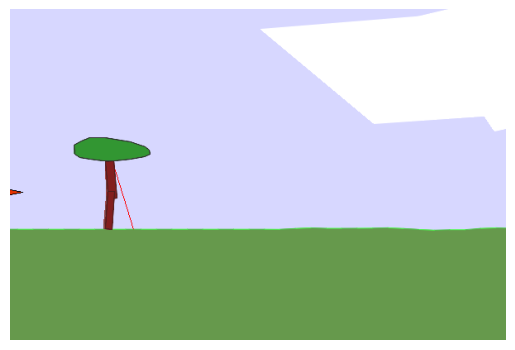

In [16]:
env = rld.make("rldurham/Walker", render_mode="rgb_array")
# env = rld.make("rldurham/Walker", render_mode="rgb_array", hardcore=True) # only attempt this when your agent has solved the non-hardcore version

# get statistics, logs, and videos
env = rld.Recorder(
    env,
    smoothing=10,                       # track rolling averages (useful for plotting)
    video=True,                         # enable recording videos
    video_folder="videos",              # folder for videos
    video_prefix="mwvy59-agent-video",  # prefix for videos (replace xxxx00 with your username)
    logs=True,                          # keep logs
)

# training on CPU recommended
rld.check_device()

# environment info
rld.env_info(env, print_out=True)

# render start image (reset just to render image)
env.reset(seed=42)
rld.render(env)

**Collect episodes and train the agent**

In [17]:
# in the submission please use seed_everything with seed 42 for verification
seed, observation, info = rld.seed_everything(42, env)

# 参数设计
env_with_Dead = True  # Whether the Env has dead state. True for Env like BipedalWalkerHardcore-v3, CartPole-v0. False for Env like Pendulum-v0
discrete_act, discrete_obs, act_dim, obs_dim = rld.env_info(env)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
max_action = float(env.action_space.high[0])
expl_noise = 0.25
print('  state_dim:', state_dim, '  action_dim:', action_dim, '  max_a:', max_action, '  min_a:', env.action_space.low[0])
kwargs = {
    "env_with_Dead": env_with_Dead,
    "state_dim": state_dim,
    "action_dim": action_dim,
    "max_action": max_action,
    "gamma": 0.99,
    "net_width": 200,
    "a_lr": 1e-4,
    "c_lr": 1e-4,
    "Q_batchsize": 256,
}
max_episodes = 1000

# initialise agent, replay_buffer
agent = Agent(**kwargs)
replay_buffer = ReplayBuffer(state_dim, action_dim, max_size=int(1e6))

# track statistics for plotting
tracker = rld.InfoTracker()

# switch video recording off (only switch on every x episodes as this is slow)
env.video = False

# training procedure
for episode in range(max_episodes):

    # recording statistics and video can be switched on and off (video recording is slow!)
    env.info = True  # usually tracking every episode is fine
    env.video = episode % 100 == 0  # record videos every 100 episodes (set BEFORE calling reset!)

    # reset for new episode
    state, info = env.reset()

    # run episode
    ep_r = 0
    steps = 0
    expl_noise *= 0.999
    done = False
    while not done:
        steps += 1

        # select the agent action
        action = (agent.sample_action(state) + np.random.normal(0, max_action * expl_noise, size=action_dim)
                ).clip(-max_action, max_action)

        # take action in the environment
        observation, reward, terminated, truncated, info = env.step(action)


        # remember
        if reward <= -100:
            agent.put_data(replay_buffer, state, action, -1, observation, True)
        else:
            agent.put_data(replay_buffer, state, action, reward, observation, False)

        # check whether done
        done = terminated or truncated
        state = observation
        ep_r += reward

        # train the agent after each step
        if replay_buffer.size > 2000:
            agent.train(replay_buffer)

    # track and plot statistics
    tracker.track(info)
    if (episode + 1) % 10 == 0:
        tracker.plot(r_mean_=True, r_std_=True, r_sum=dict(linestyle=':', marker='x'))
    print('episode:', episode, 'score:', ep_r, 'step:', steps)
# don't forget to close environment (e.g. triggers last video save)
env.close()

# write log file (for coursework)
env.write_log(folder="logs", file="xxxx00-agent-log.txt")  # replace xxxx00 with your username

episode:199, 	Reward:-100
episode:200, 	Reward:-100


KeyboardInterrupt: 